In [1]:
import numpy as np
import soundfile as sf
from scipy.signal import fftconvolve
from IPython.display import Audio
import matplotlib.pyplot as plt
from __future__ import annotations
from dataclasses import dataclass
from typing import Iterable, List, Tuple, Optional, Dict
import numpy as np



### This project implements the first order SDN network from the Efficient Synthesis of Room Acoustics via Scattering Delay Networks by Enzo De Sena et al, 2015
from the paper, we can see the transfer function for the SDN network is as followed

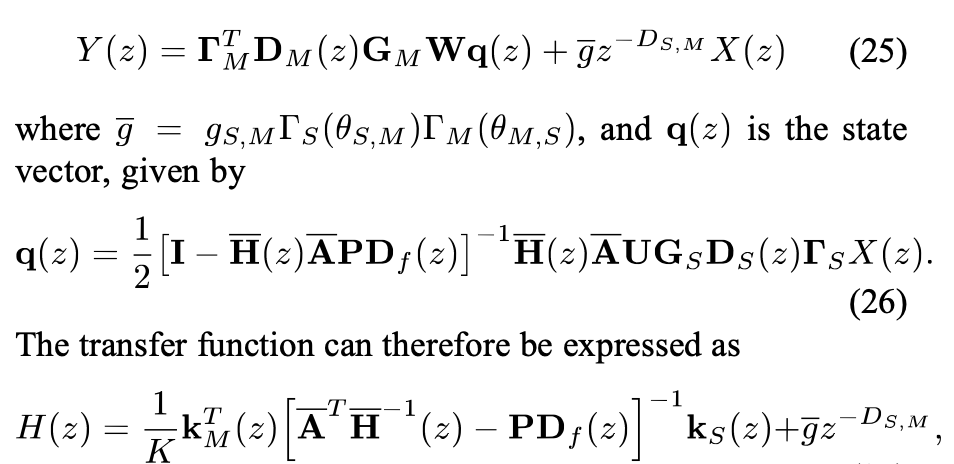

## Some simplifications in this implementation:
1. Source directivity Γ_S is omnidirectional, so Γ_S = 1.
2. Microphone directivity Γ_M is omnidirectional, so Γ_M = 1.
3. Wall absorption H(z) is not frequncy dependant, H(z) ≈ beta instead of a frequency-dependent wall filter.

## Some Analysis after the simplification
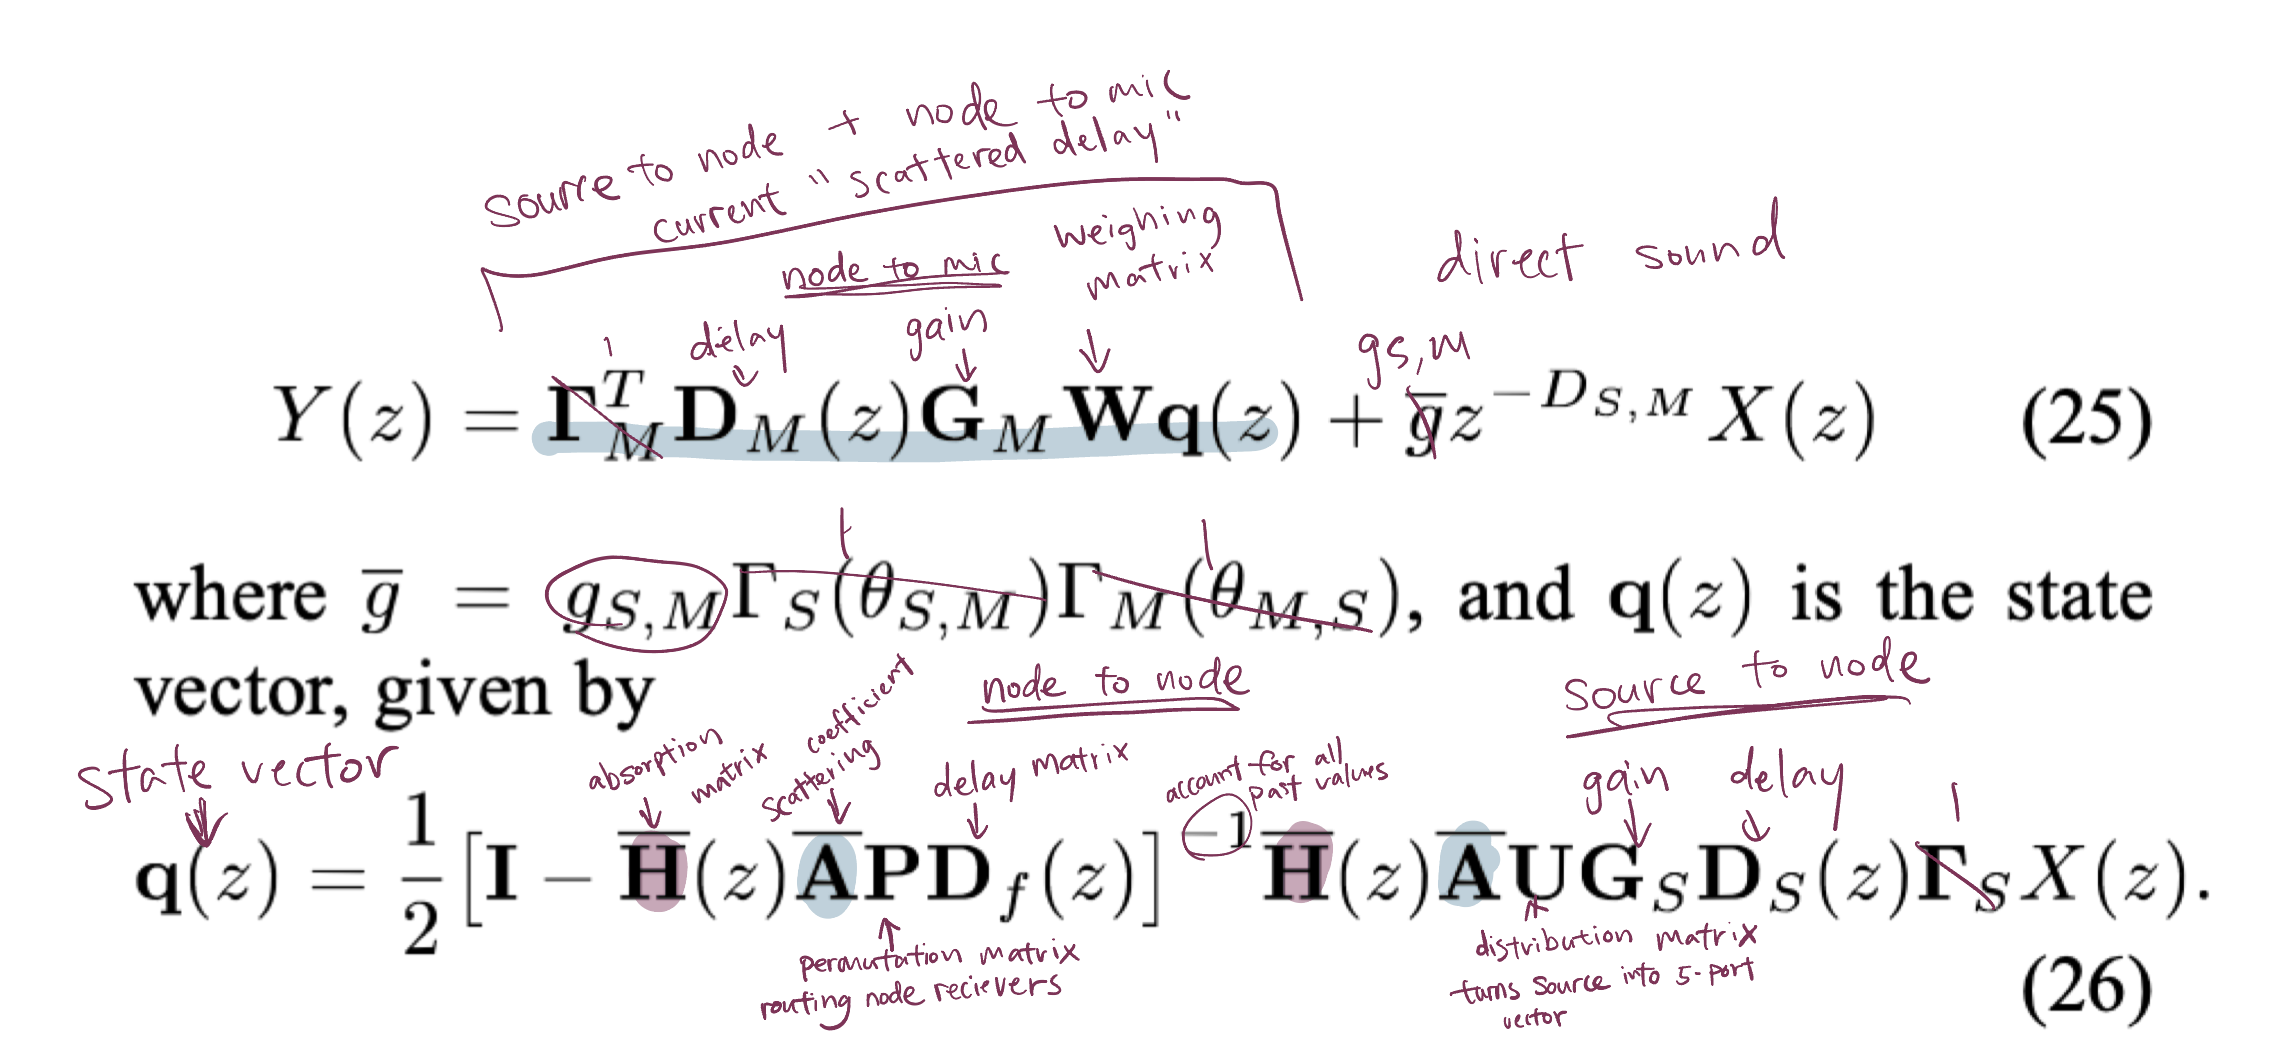

In [2]:
fs = 44100
c = 343#343.0  #speed of sound, meters per second

#Lx, Ly, Lz
room_dims = np.array([30.0, 30.0, 30.0]) 

source = np.array([1.0, 1.5, 1.2])
mic = np.array([4.5, 3.2, 20.4])

## Functions to get delay and attenuation:

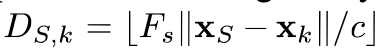

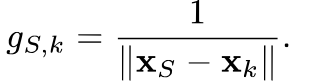

In [3]:
def dist(a, b):
    return np.linalg.norm(a - b)

#to calculate how many samples it takes to get to for a certain distance
def delay_samples(dist, fs, c=343.0):
    return int(np.round(dist / c * fs))
#gain 
def attenuation(dist, eps=1e-8):
    return 1.0 / max(dist, eps)

## scattering matrix, used isotropic scattering matrix
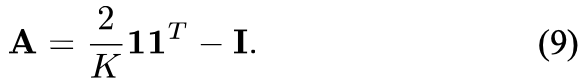

In [7]:
#scattering matrix, used isotropic scattering matrix, as above
K = 6
N_ports = K-1 

A_node = (2.0 / N_ports) * np.ones((N_ports, N_ports)) - np.eye(N_ports)

print(A_node)

[[-0.6  0.4  0.4  0.4  0.4]
 [ 0.4 -0.6  0.4  0.4  0.4]
 [ 0.4  0.4 -0.6  0.4  0.4]
 [ 0.4  0.4  0.4 -0.6  0.4]
 [ 0.4  0.4  0.4  0.4 -0.6]]


## Actual Implementation

In [8]:
@dataclass(frozen=True)
class RectRoom:

    # Axis-aligned rectangular room with corners at (0,0,0) and (Lx, Ly, Lz).

    # The SDN paper places one scattering node on each major reflecting surface.
    # For a 3D rectangular room, this gives 6 wall nodes:

    # 0: x=0
    # 1: x=Lx
    #2: y=0
    #3: y=Ly
    #4: z=0
    # 5: z=Lz


    Lx: float
    Ly: float
    Lz: float

    def wall_plane(self, wall_id: int) -> Tuple[np.ndarray, float]:

        if wall_id == 0:
            n = np.array([1.0, 0.0, 0.0]); d = 0.0
        elif wall_id == 1:
            n = np.array([1.0, 0.0, 0.0]); d = self.Lx
        elif wall_id == 2:
            n = np.array([0.0, 1.0, 0.0]); d = 0.0
        elif wall_id == 3:
            n = np.array([0.0, 1.0, 0.0]); d = self.Ly
        elif wall_id == 4:
            n = np.array([0.0, 0.0, 1.0]); d = 0.0
        elif wall_id == 5:
            n = np.array([0.0, 0.0, 1.0]); d = self.Lz
        else:
            raise ValueError("wall_id must be 0..5")

        return n, float(d)

    def reflect_point_across_wall(self, p: np.ndarray, wall_id: int) -> np.ndarray:
        
        #Reflect a point across a wall plane.

        n, d = self.wall_plane(wall_id)
        dist = float(np.dot(n, p) - d)

        # Reflection formula:
        #   p_reflected = p - 2 * signed_distance * normal
        return p - 2.0 * dist * n

    def first_order_reflection_point(
        self,
        source: np.ndarray,
        mic: np.ndarray,
        wall_id: int
    ) -> np.ndarray:
        # 
        # Compute the first-order specular reflection point on a wall, wall node position x_k.

        #     1. Reflect source across the wall, forming an image source.
        #     2. Draw a line from the image source to the microphone.
        #     3. Intersect that line with the wall.
        # 

        img = self.reflect_point_across_wall(source, wall_id)
        n, d = self.wall_plane(wall_id)

        v = mic - img
        denom = float(np.dot(n, v))

        if abs(denom) < 1e-12:
            # Rare fallback if the image-source-to-mic line is nearly parallel
            # to the wall plane.
            dist = float(np.dot(n, source) - d)
            return source - dist * n

        t = (d - float(np.dot(n, img))) / denom
        xk = img + t * v

        xk = np.array(xk, dtype=np.float64)
        xk[0] = np.clip(xk[0], 0.0, self.Lx)
        xk[1] = np.clip(xk[1], 0.0, self.Ly)
        xk[2] = np.clip(xk[2], 0.0, self.Lz)

        return xk


In [11]:
def _norm(x: np.ndarray) -> float:
    #calculate distaices
    #These distances determine delay terms such as:D_S(z), D_f(z), D_M(z), and z^{-D_{S,M}}
        
    return float(np.linalg.norm(x))

In [12]:
class FractionalDelayLine:

    #circulating delay line with linear interpolation.


    def __init__(self, max_delay_samples: int):
        if max_delay_samples < 2:
            max_delay_samples = 2
        self.buf = np.zeros(max_delay_samples + 2, dtype=np.float64)
        self.N = len(self.buf)
        self.w = 0  # write index

    #This is the implementation of z^{-D}.
    def process(self, x: float, delay_samples: float) -> float:

        # Write current sample.
        self.buf[self.w] = x

        #clip delay to valid buffer range.
        d = float(delay_samples)
        if d < 0:
            d = 0.0
        if d > self.N - 2:
            d = self.N - 2.0

        #read position corresponding to current write position minus delay
        r = self.w - d
        r0 = int(np.floor(r))
        frac = r - r0

        #wrap indices.
        i0 = r0 % self.N
        i1 = (r0 - 1) % self.N

        #Linear interpolation for fractional delay.
        y = (1.0 - frac) * self.buf[i0] + frac * self.buf[i1]

        # update write index.
        self.w = (self.w + 1) % self.N

        return float(y)

In [13]:
class SDNReverb:

    def __init__(
        self,
        room: RectRoom,
        fs: float,
        c: float = 343.0,
        wall_absorption: Iterable[float] = (0.2, 0.2, 0.2, 0.2, 0.2, 0.2),
        max_rt_seconds: float = 3.0,
    ):
        self.room = room
        self.fs = float(fs)
        self.c = float(c)

        # Wall absorption term Hbar(z)
        #   beta_k = sqrt(1 - alpha_k)
        
        alpha = np.array(list(wall_absorption), dtype=np.float64)
        alpha = np.clip(alpha, 0.0, 0.999999)
        self.beta = np.sqrt(1.0 - alpha)

        #N->number of nodes; K->number of ports per node
        self.N = 6
        self.K = 5

        # Scattering matrix A Isotropic scattering
        ones = np.ones((self.K, 1), dtype=np.float64)
        self.A = (2.0 / self.K) * (ones @ ones.T) - np.eye(self.K, dtype=np.float64)

        # Maximum delay-line capacity.
        self.max_delay_samples = int(np.ceil(max_rt_seconds * self.fs)) + 1024

        self._configured = False

    def configure(self, source_pos: np.ndarray, mic_pos: np.ndarray):

        xs = np.array(source_pos, dtype=np.float64).reshape(3)
        xm = np.array(mic_pos, dtype=np.float64).reshape(3)

        # Wall-node positions x_k
        self.xk = np.stack(
            [self.room.first_order_reflection_point(xs, xm, wid)
             for wid in range(self.N)],
            axis=0
        )

        # Direct path: g_bar z^{-D_{S,M}}
        d_sm = _norm(xs - xm)
        self.g_direct = 1.0 / max(d_sm, 1e-6)#prevent from getting too big
        self.d_direct = (d_sm / self.c) * self.fs
        self.dl_direct = FractionalDelayLine(self.max_delay_samples)


        # Port topology and permutation matrix P
        # neigh: keeps the neighbor; porof:Find the port index at node j that receives signal from node k
        self.neigh: List[List[int]] = []
        self.port_of: List[Dict[int, int]] = []

        for i in range(self.N):
            others = [j for j in range(self.N) if j != i]
            self.neigh.append(others)
            self.port_of.append({j: p for p, j in enumerate(others)})

        # Source-to-node path:
        #     G_S D_S(z) Γ_S

        self.dl_s2k: List[FractionalDelayLine] = []
        self.d_s2k = np.zeros(self.N, dtype=np.float64)
        self.g_s2k = np.zeros(self.N, dtype=np.float64)

        for k in range(self.N):
            d = _norm(xs - self.xk[k])
            self.d_s2k[k] = (d / self.c) * self.fs
            self.g_s2k[k] = 1.0 / max(d, 1e-6)
            self.dl_s2k.append(FractionalDelayLine(self.max_delay_samples))

        # Inter-node feedback delays D_f(z)
        self.dl_k2j: List[List[FractionalDelayLine]] = [[None] * self.N for _ in range(self.N)]
        self.d_k2j = np.zeros((self.N, self.N), dtype=np.float64)

        for k in range(self.N):
            for j in range(self.N):
                if j == k:
                    continue

                d = _norm(self.xk[k] - self.xk[j])
                self.d_k2j[k, j] = (d / self.c) * self.fs
                self.dl_k2j[k][j] = FractionalDelayLine(self.max_delay_samples)

        # Node-to-microphone path:
        #     D_M(z) G_M W
   
        self.dl_k2m: List[FractionalDelayLine] = []
        self.d_k2m = np.zeros(self.N, dtype=np.float64)
        self.g_k2m = np.zeros(self.N, dtype=np.float64)

        for k in range(self.N):
            d_km = _norm(self.xk[k] - xm)
            self.d_k2m[k] = (d_km / self.c) * self.fs

            d_sk = max(_norm(xs - self.xk[k]), 1e-6)
            self.g_k2m[k] = 1.0 / (1.0 + (d_km / d_sk))

            self.dl_k2m.append(FractionalDelayLine(self.max_delay_samples))


        #recursive state q(z)
        self.in_waves = np.zeros((self.N, self.K), dtype=np.float64)

        self._configured = True

    def process(self, x: np.ndarray) -> np.ndarray:
        
        # returns the SDN output 

        # For each sample:
        #     1. Compute the direct path:
        #            g_bar z^{-D_{S,M}}

        #     2. source energy into wall nodes:
        #            k_S(z) = U G_S D_S(z) Γ_S

        #     3. scatter and absortion at wall nodes
        #            Hbar(z) Abar

        #     4. Send output to the microphone:
        #            k_M^T(z) = Γ_M^T D_M(z) G_M W

        #     5. send the rest through inter-node delays and routing:
        #            P D_f(z)

        #     6. Store the result as the next incoming state
        

        x = np.asarray(x, dtype=np.float64).reshape(-1)
        y = np.zeros_like(x)

        for n in range(len(x)):
            xn = float(x[n])

            # Direct path: g_bar z^{-D_{S,M}}
            # This bypasses the wall-scattering network and is added directly to the output
            y_direct = self.g_direct * self.dl_direct.process(xn, self.d_direct)

            # next_in will become the next sample's incoming wave state.
            # This implements the feedback/routing part of the recursive
            # network.
            next_in = np.zeros_like(self.in_waves)

            # Accumulator for reflected/reverberant node contributions.
            y_nodes = 0.0

            for k in range(self.N):

                # Source-to-node path: k_S(z) = U G_S D_S(z) Γ_S
                # Γ_S = 1
                s_k = self.g_s2k[k] * self.dl_s2k[k].process(xn, self.d_s2k[k])

                # Source injection matrix U, distributes the source pressure uniformly into the incoming wave variables 
                #adding 0.5 * s_k to all ports approximates the soft-source injection into the incoming wave vector
                in_vec = self.in_waves[k] + 0.5 * s_k

                #Scattering and wall absorption: Hbar(z) Abar
                out_vec = self.beta[k] * (self.A @ in_vec)

                #maps outgoing wave variables to the signal senttoward the microphone
                # For equal-admittance physical scattering, node pressure can be approximated by
                #       p_e = (2/K) 1^T out_vec

                p_e = (2.0 / self.K) * float(np.sum(out_vec))

                # Node-to-microphone path:
                #       Γ_M^T D_M(z) G_M W
                # g_k2m[k] = G_M,k
                # dl_k2m[k] = D_M,k(z)
                y_nodes += self.g_k2m[k] * self.dl_k2m[k].process(p_e, self.d_k2m[k])

                # Inter-node feedback network:P D_f(z)
                # The routing:outgoing from node k toward node j → incoming port at node j that correspondsto node k
                #permutation matrix P.
                for j in self.neigh[k]:
                    # Port at node k pointing toward neighbor j.
                    p = self.port_of[k][j]

                    #outgoing wave on this port.
                    sig = float(out_vec[p])

                    #propagation delay from node k to node j.
                    delayed = self.dl_k2j[k][j].process(sig, self.d_k2j[k, j])

                    #at destination node j, find the port that receives waves from node k
                    pj = self.port_of[j][k]

                    #route delayed signal into next incoming state.
                    next_in[j, pj] += delayed

            # update recursive state q(z)
            # The network's previous outgoing waves become the next sample's incoming waves after delay and routing.
            self.in_waves = next_in


            #summing output, y[n] = direct path + reflected/reverberant path
            
            y[n] = y_direct + y_nodes

        return y

In [21]:
fs = 44100#48000
room = RectRoom(Lx=3.0, Ly=15.0, Lz=15.0)
sdn = SDNReverb(room, fs=fs, wall_absorption=(0.25, 0.25, 0.35, 0.35, 0.2, 0.2), max_rt_seconds=2.5)

source = np.array([1.0, 1.5, 1.2])
mic = np.array([2.5, 10.2, 7.4])
sdn.configure(source, mic)

# impulse
x = np.zeros(int(fs * 2.0))
x[0] = 1.0
h = sdn.process(x)

# h is the synthesized SDN RIR for these positions
print("RIR length:", len(h), "samples. Peak:", np.max(np.abs(h)))
x


RIR length: 88200 samples. Peak: 0.09056895100068722


array([1., 0., 0., ..., 0., 0., 0.], shape=(88200,))

In [27]:
a, Sr = sf.read("inmyroom.wav")
Audio(a, rate = Sr)


In [28]:
y = fftconvolve(a, h, mode="full")
y = y / max(abs(y))
Audio(y, rate = Sr)

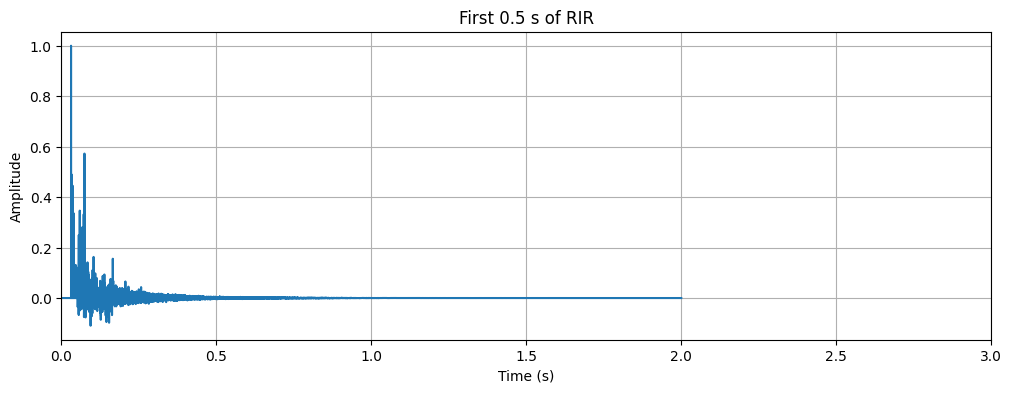

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.signal import fftconvolve

# Normalize RIR for inspection
h_norm = h /(np.max(np.abs(h)) )

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(h_norm))/fs, h_norm)
plt.xlim(0, 3)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("First 0.5 s of RIR")
plt.grid(True)
plt.show()